# ASTR 223 Final Project: Projection Model Implementation

Some source code taken from: https://num.pyro.ai/en/stable/examples/baseball.html

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pybaseball import batting_stats

import argparse
import os

import powerlaw

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option('display.max_columns', None)

## modeling libraries
import jax
import jax.numpy as jnp
import jax.random as random
from jax.scipy.special import logsumexp

import numpyro
import numpyro.distributions as dist
from numpyro.examples.datasets import BASEBALL, load_dataset
from numpyro.infer import HMC, MCMC, NUTS, SA, Predictive, log_likelihood
from numpyro.infer.mcmc import MCMC

import arviz as az

from scipy.stats import pearsonr

blue_color = '#1E90FF'
red_color = '#EF3E42'
color_palette = {0: blue_color, 1: red_color}

In [2]:
seed = 42
key = jax.random.key(seed)
numpyro.set_host_device_count(6)
jax.config.update("jax_enable_x64", True) ## makes the arrays a little more precise

In [3]:
batted_ball_data = pd.read_parquet('data/batted_balls_w_xhrs.parquet')
player_data = pd.read_parquet('data/player_primary_pos_w_xhrs.parquet')

## this is our goal --> we're doing it by batted ball events not just plate appearences b/c we modeled xHRs with just EV and LA
player_data['xHR%'] = player_data['xHR'] / player_data['events']

possible_pos = ['C', '1B', '2B', '3B', 'SS', 'LF', 'CF', 'RF', 'DH']

In [4]:
# these are HR ballpark factors
ballpark_factors = {
    'ARI': {2020: 112, 2021: 89, 2022: 86, 2023: 84, 2024: 86, 2025: 88},
    # 2025 for ATH is 100 b/c they played in SAC
    'ATH': {2020: 85, 2021: 85, 2022: 80, 2023: 84, 2024: 81, 2025: 100},
    'ATL': {2020: 94, 2021: 103, 2022: 104, 2023: 111, 2024: 105, 2025: 104},
    'BAL': {2020: 118, 2021: 124, 2022: 108, 2023: 104, 2024: 93, 2025: 105},
    'BOS': {2020: 92, 2021: 91, 2022: 99, 2023: 99, 2024: 98, 2025: 89},
    'CHC': {2020: 92, 2021: 104, 2022: 103, 2023: 106, 2024: 93, 2025: 99},
    'CHW': {2020: 107, 2021: 113, 2022: 113, 2023: 104, 2024: 98, 2025: 96},
    'CIN': {2020: 106, 2021: 126, 2022: 139, 2023: 131, 2024: 128, 2025: 123},
    'CLE': {2020: 101, 2021: 102, 2022: 98, 2023: 89, 2024: 86, 2025: 85},
    'COL': {2020: 118, 2021: 112, 2022: 108, 2023: 108, 2024: 109, 2025: 106},
    'DET': {2020: 93, 2021: 84, 2022: 76, 2023: 79, 2024: 86, 2025: 99},
    'HOU': {2020: 106, 2021: 106, 2022: 100, 2023: 101, 2024: 107, 2025: 105},
    'KCR': {2020: 80, 2021: 76, 2022: 80, 2023: 84, 2024: 85, 2025: 85},
    'LAA': {2020: 112, 2021: 107, 2022: 114, 2023: 112, 2024: 112, 2025: 113},
    'LAD': {2020: 119, 2021: 124, 2022: 126, 2023: 122, 2024: 122, 2025: 127},
    'MIA': {2020: 74, 2021: 81, 2022: 84, 2023: 86, 2024: 92, 2025: 90},
    'MIL': {2020: 110, 2021: 105, 2022: 110, 2023: 109, 2024: 114, 2025: 106},
    'MIN': {2020: 93, 2021: 99, 2022: 100, 2023: 104, 2024: 105, 2025: 102},
    'NYM': {2020: 105, 2021: 102, 2022: 95, 2023: 95, 2024: 99, 2025: 104},
    'NYY': {2020: 115, 2021: 111, 2022: 115, 2023: 116, 2024: 119, 2025: 119},
    'PHI': {2020: 116, 2021: 114, 2022: 113, 2023: 113, 2024: 115, 2025: 114},
    'PIT': {2020: 84, 2021: 81, 2022: 84, 2023: 80, 2024: 84, 2025: 76},
    'SDP': {2020: 99, 2021: 98, 2022: 100, 2023: 93, 2024: 104, 2025: 102},
    'SFG': {2020: 74, 2021: 79, 2022: 83, 2023: 84, 2024: 78, 2025: 82},
    'SEA': {2020: 100, 2021: 99, 2022: 100, 2023: 98, 2024: 96, 2025: 93},
    'STL': {2020: 86, 2021: 81, 2022: 84, 2023: 90, 2024: 91, 2025: 87},
    # 2025 for TBR is 100 b/c they played at steinbrenner field
    'TBR': {2020: 83, 2021: 84, 2022: 87, 2023: 94, 2024: 98, 2025: 100},
    # 2020-2021 for TEX is 100 b/c they hadn't played full seasons at globe field yet (opened in 2019)
    'TEX': {2020: 100, 2021: 100, 2022: 101, 2023: 111, 2024: 115, 2025: 104},
    'TOR': {2020: 117, 2021: 117, 2022: 111, 2023: 104, 2024: 103, 2025: 104}, 
    'WSN': {2020: 111, 2021: 109, 2022: 108, 2023: 107, 2024: 101, 2025: 94},
    # this handles all of the players who played for multiple teams in a single season --> easy way to account for them 
    '--': {2020: 100, 2021: 100, 2022: 100, 2023: 100, 2024: 100, 2025: 100},
    }
ballpark_data = pd.DataFrame(ballpark_factors).T.reset_index(names='team')
park_long = ballpark_data.melt(id_vars='team', var_name='game_year', value_name='park_factor')
park_long['park_factor'] = park_long['park_factor'] / 100.0
## we add 1 because each year is associated with the next year for the projection (2020 meant 2018-2020 to be used for 2021, and so on)
park_long['game_year'] = park_long['game_year'] + 1

## EDA

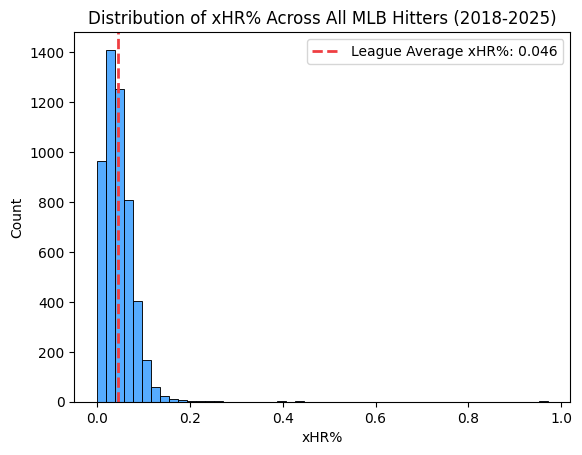

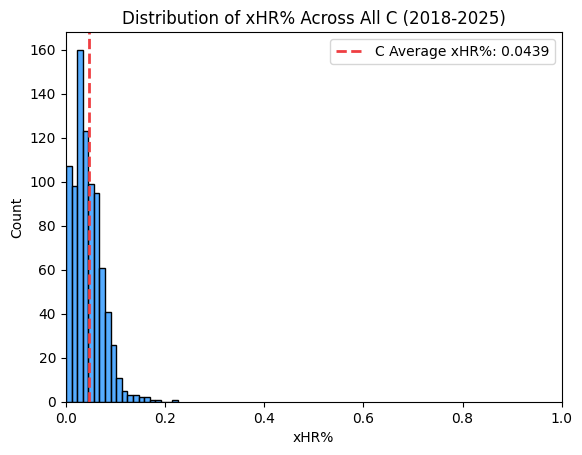

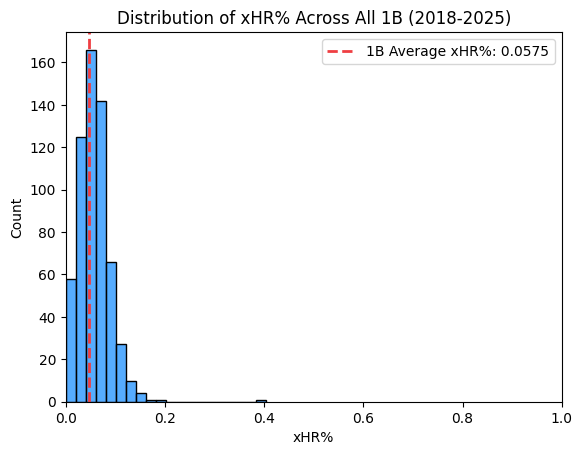

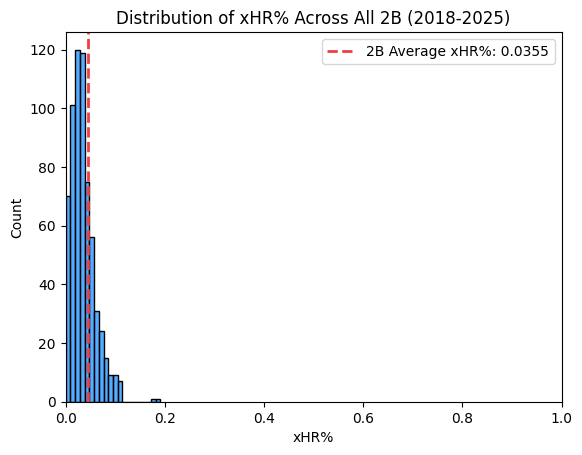

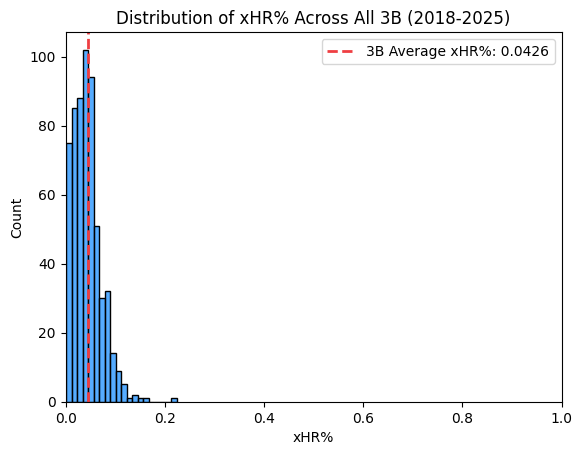

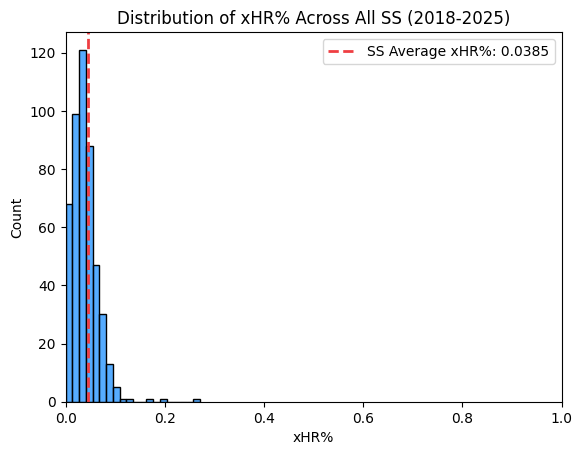

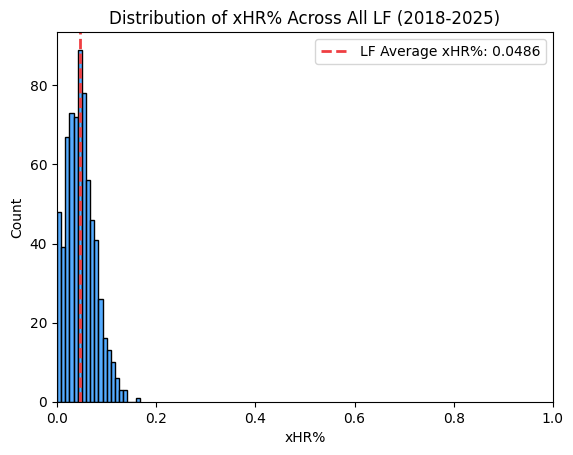

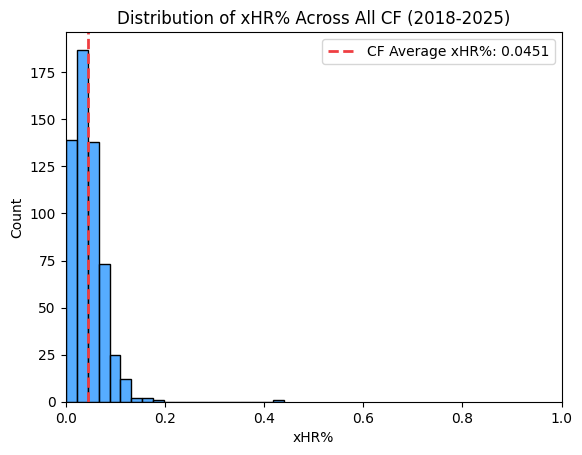

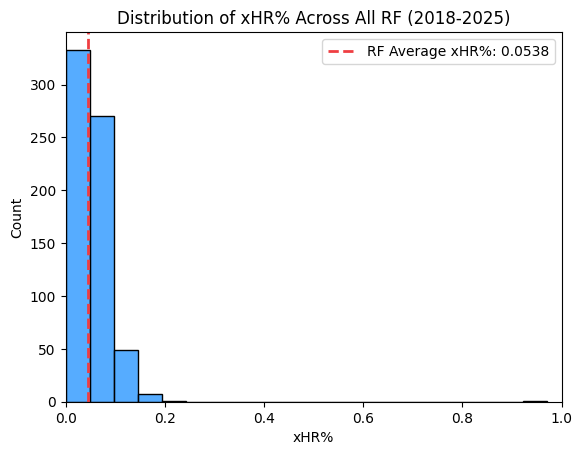

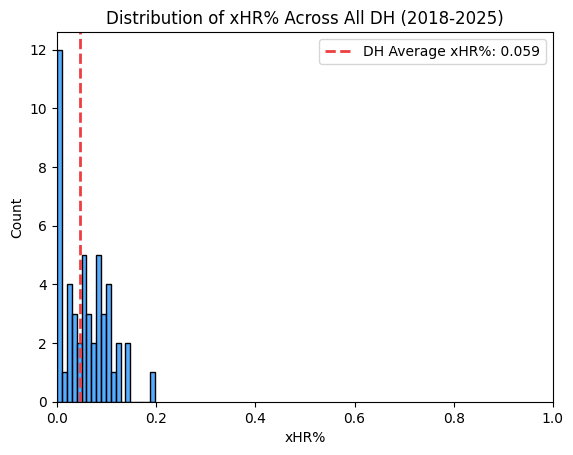

,count,mean,std,min,25%,50%,75%,max
primary_pos,,,,,,,,
C,839.0,0.043871,0.030043,0.000276,0.023145,0.039210,0.060950,0.225747
1B,601.0,0.057455,0.032986,0.000610,0.036908,0.053758,0.075295,0.404004
2B,638.0,0.035512,0.024344,0.000085,0.018380,0.031136,0.046668,0.190884
3B,591.0,0.042628,0.028122,0.000643,0.021080,0.039290,0.056321,0.223590
SS,476.0,0.038510,0.026567,0.000157,0.021499,0.034306,0.051691,0.271213
LF,687.0,0.048612,0.028428,0.000315,0.028083,0.046167,0.066348,0.167055
CF,580.0,0.045072,0.033262,0.000501,0.023172,0.040892,0.060310,0.440163
RF,661.0,0.053779,0.048282,0.000300,0.029925,0.048245,0.070615,0.971081
DH,50.0,0.059040,0.047322,0.000483,0.021072,0.055999,0.090796,0.197255


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 5121/5121 [00:08<00:00, 592.25it/s] 


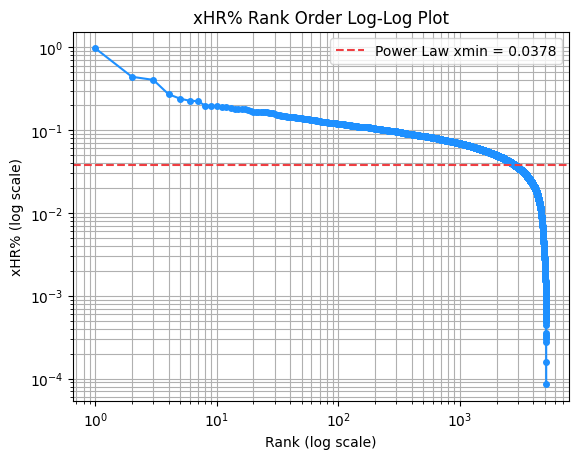

In [5]:
# some EDA on the distribution of xHR%

plt.figure()
sns.histplot(data=player_data, x='xHR%', color=blue_color, bins=50,)
plt.title('Distribution of xHR% Across All MLB Hitters (2018-2025)')
plt.axvline(x=player_data['xHR%'].mean(), color=red_color, linewidth = 2, linestyle='--', label=rf'League Average xHR%: {player_data['xHR%'].mean():.3}')
plt.legend()
plt.show()

for pos in possible_pos:
    pos_data = player_data[player_data['primary_pos'] == pos]
    plt.figure()
    sns.histplot(data=pos_data, x='xHR%', color=blue_color, bins=20,)
    plt.title(f'Distribution of xHR% Across All {pos} (2018-2025)')
    plt.axvline(x=player_data['xHR%'].mean(), color=red_color, linewidth = 2, linestyle='--', label=rf'{pos} Average xHR%: {pos_data['xHR%'].mean():.3}')
    plt.legend()
    plt.xlim(0, 1)
    plt.show()

display(player_data.groupby('primary_pos')['xHR%'].describe().reindex(possible_pos))

sorted_xhrs = np.sort(player_data['xHR%'])[::-1]
xhr_ranks = np.arange(1, len(sorted_xhrs) + 1)
fit = powerlaw.Fit(sorted_xhrs)
xmin = fit.power_law.xmin
plt.figure()
plt.loglog(xhr_ranks, sorted_xhrs, marker='o', linestyle='-', markersize=4, color=blue_color)
plt.axhline(xmin, label=f'Power Law xmin = {xmin:.4f}', color=red_color, linestyle='--')
plt.xlabel('Rank (log scale)')
plt.ylabel('xHR% (log scale)')
plt.title(f'xHR% Rank Order Log-Log Plot')
plt.grid(True, which="both", ls="-")
# plt.xlim(1, len(sorted_xhrs))
# plt.ylim(min(sorted_xhrs)*0.9, max(sorted_xhrs)*1.1)
plt.legend()
plt.show()

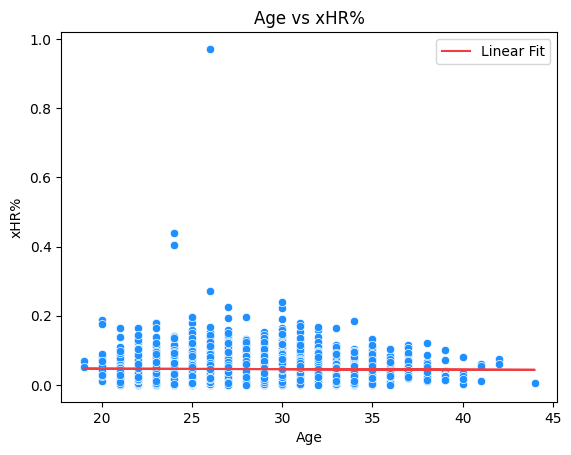

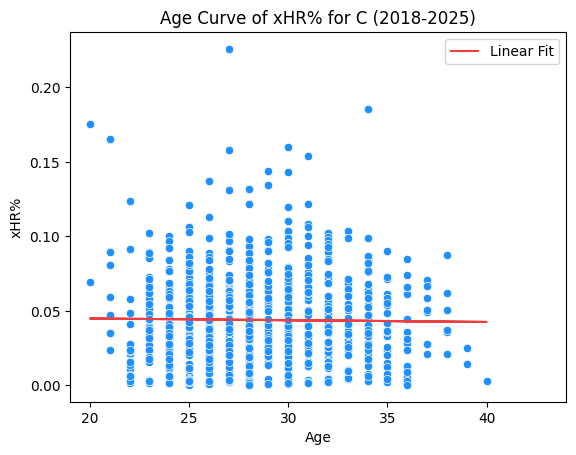

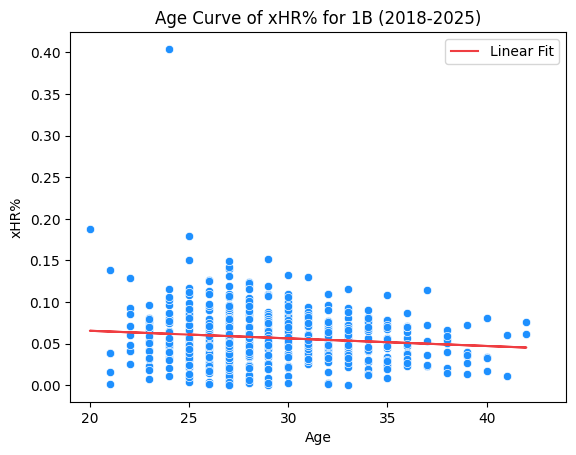

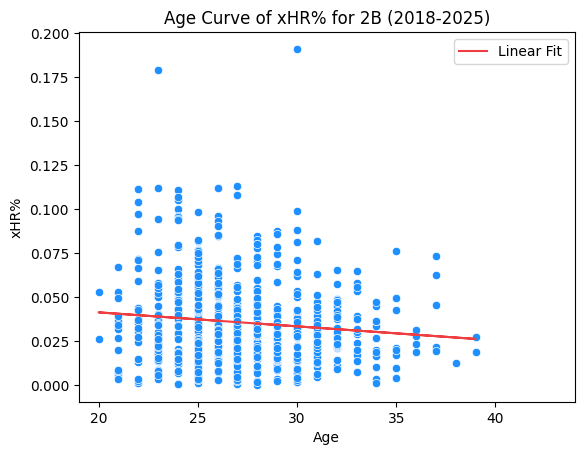

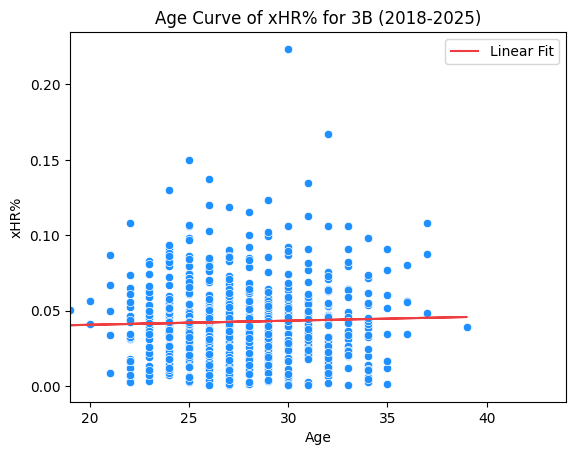

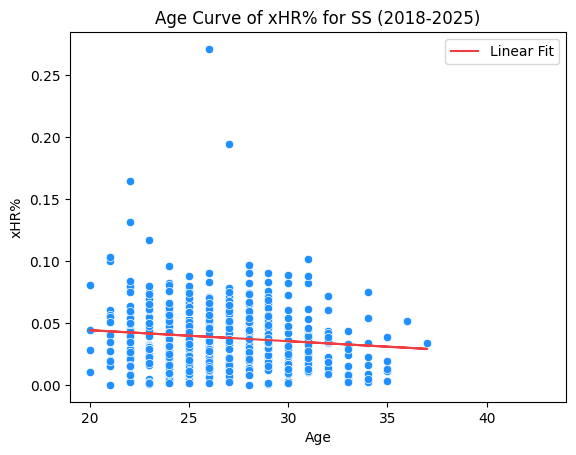

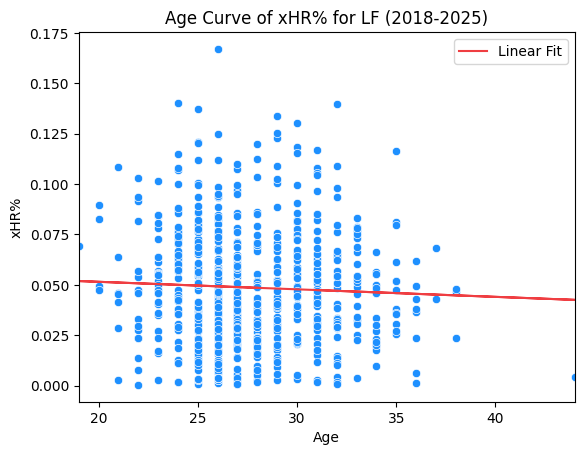

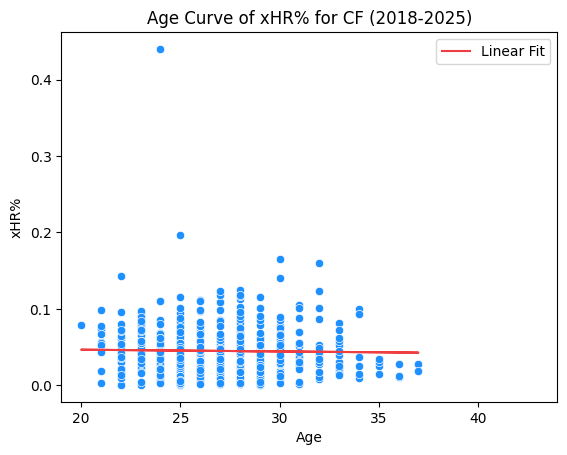

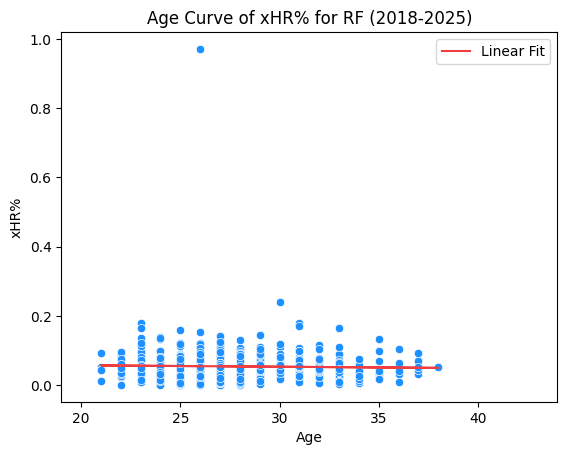

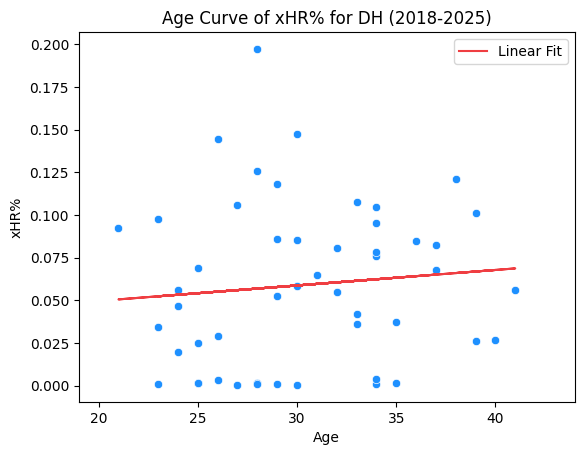

In [6]:
# age curve eda

plt.figure()
sns.scatterplot(data=player_data, x='Age', y='xHR%', color=blue_color)
m, b = np.polyfit(player_data['Age'], player_data['xHR%'], 1)
plt.plot(player_data['Age'], m*player_data['Age'] + b, color=red_color, label='Linear Fit')
plt.legend()
plt.title('Age vs xHR%')
plt.show()

for pos in possible_pos:
    pos_data = player_data[player_data['primary_pos'] == pos]
    plt.figure()
    sns.scatterplot(data=pos_data, x='Age', y='xHR%',color=blue_color)
    m_pos, b_pos = np.polyfit(pos_data['Age'], pos_data['xHR%'], 1)
    plt.plot(pos_data['Age'], m_pos*pos_data['Age'] + b_pos, color=red_color, label='Linear Fit')
    plt.title(f'Age Curve of xHR% for {pos} (2018-2025)')
    plt.legend()
    plt.xlim(player_data['Age'].min(), player_data['Age'].max())
    plt.show()

In [7]:
player_data['xHR%'].var()

np.float64(0.00110733978122369)

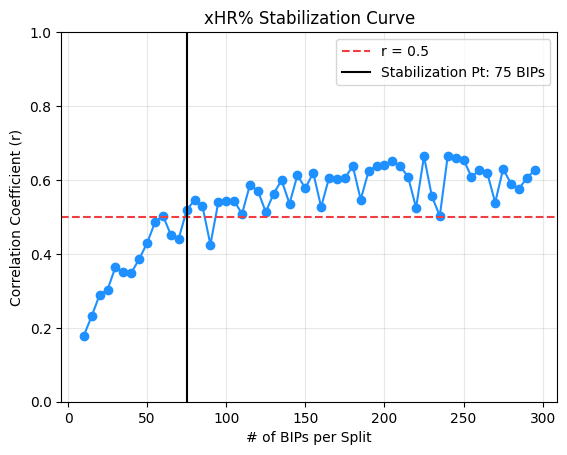

In [8]:
batted_ball_data = batted_ball_data.sort_values(by=['batter', 'game_year', 'game_date'], ascending=[True, True, True]).reset_index(drop=True).copy()
batted_ball_data['batted_ball_no'] = batted_ball_data.groupby(['batter', 'game_year']).cumcount() + 1

thresholds = np.arange(10, 300, 5)
corrs = []
stabilize_n = []

for n in thresholds:
    ## bucket 1 contains the first half of n batted balls
    bucket_1 = batted_ball_data[batted_ball_data['batted_ball_no'] <= n]
    rate_1 = bucket_1.groupby(['batter', 'game_year'])['xHR'].mean().rename('first_n')

    ## bucket 2 contains the second half of n batted balls
    bucket_2 = batted_ball_data[(batted_ball_data['batted_ball_no'] > n) & (batted_ball_data['batted_ball_no'] <= 2 * n)]
    rate_2 = bucket_2.groupby(['batter', 'game_year'])['xHR'].mean().rename('next_n')

    merged_rates = pd.concat([rate_1, rate_2], axis=1).dropna()
    r, p_val = pearsonr(merged_rates['first_n'], merged_rates['next_n'])
    corrs.append(r)
    stabilize_n.append(n)

for i in range(len(corrs) - 1):
    if corrs[i] >= 0.50 and corrs[i+1] >= 0.50:
        stabilization_pt = stabilize_n[i]
        break

plt.figure()
plt.plot(stabilize_n, corrs, marker='o', linestyle='-', color=blue_color)
plt.axhline(0.50, color=red_color, linestyle='--', label='r = 0.5')
plt.axvline(stabilization_pt, color='k', linestyle='-', label=f'Stabilization Pt: {stabilization_pt:.0f} BIPs')
plt.title("xHR% Stabilization Curve")
plt.xlabel("# of BIPs per Split")
plt.ylabel("Correlation Coefficient (r)")
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Data Prep for Modeling

In [9]:
# finds the team played for every player from every season 

team_data = []
for yr in list(np.arange(2018, 2026)):
    yr_data = batting_stats(yr, qual=1)
    yr_data = yr_data[['IDfg', 'Season', 'Team']]
    team_data.append(yr_data)
player_teams = pd.concat(team_data, ignore_index=True).copy()
## adds the team that the player played for in that season
player_data = (player_data
               .merge(player_teams, how='left', left_on=['IDfg', 'game_year'], right_on=['IDfg', 'Season'])
               .drop(columns=['Season'])
               .copy()
               )
player_data['Team'] = player_data['Team'].apply(lambda x: 'ATH' if x=='OAK' else '--' if x=='- - -' else x)
player_data = player_data.merge(park_long, how='left', left_on=['game_year', 'Team'], right_on=['game_year', 'team']).drop(columns=['Team'])
## we're making the assumption that the player plays half their game at that park --> only get half the park factor
player_data['park_factor'] = player_data['park_factor'].apply(lambda x: (x + 1)/2)

In [10]:
def create_lag_features(data, lag_amount):
    """
    fetches the lag years of the data (years j-1, j-2, j-3)
    """
    lag_df = data[['game_year', 'batter', 'events', 'pos_idx', 'xHR']].copy()
    ## shifts j forward so it aligns with j+1
    lag_df['game_year'] = lag_df['game_year'] + lag_amount
    lag_df = lag_df.rename(columns={'events': f'events_lag{lag_amount}', 
                                    'xHR': f'xHR_lag{lag_amount}',
                                    'pos_idx': f'pos_idx_lag{lag_amount}',
                                    })
    return lag_df

In [11]:
# label encoding the player pos
pos_mapping = {'C': 0, '1B': 1, '2B': 2, '3B': 3, 'SS': 4, 'LF': 5, 'CF': 6, 'RF': 7, 'DH': 8}
player_data['pos_idx'] = player_data['primary_pos'].map(pos_mapping).astype(int)

# we're lagging the data so we can see the previous outcomes of the player in seasons j-1, ..., j-3 
player_data_lagged = player_data.copy()
for i in [1, 2, 3]:
    lag_data = create_lag_features(player_data, i)
    player_data_lagged = pd.merge(player_data_lagged, lag_data, on=['batter', 'game_year'], how='left').copy()
    
for i in [1, 2, 3]:
    # if the lag position is missing, we assume they play their current position
    player_data_lagged[f'pos_idx_lag{i}'] = player_data_lagged[f'pos_idx_lag{i}'].fillna(player_data_lagged['pos_idx'])    
    player_data_lagged[f'events_lag{i}'] = player_data_lagged[f'events_lag{i}'].fillna(0)
    player_data_lagged[f'xHR_lag{i}'] = player_data_lagged[f'xHR_lag{i}'].fillna(0)

for col in player_data_lagged.columns:
    if 'pos_idx' in col:
        player_data_lagged[col] = player_data_lagged[col].astype(int)

## because we have the lagged results from the previous 3 seasons, we can exclude seasons 2018-2020
player_data_lagged = player_data_lagged[player_data_lagged['game_year'] >= 2021].reset_index(drop=True).copy()
player_data_lagged['batter_season'] = player_data_lagged['batter'].astype(str) + "_" + player_data_lagged['game_year'].astype(str) ## our coord system

In [25]:
master_modeling_player_data = {'bips_j': jnp.array(player_data_lagged['events'].values),
                               ## we have to our target an int because we use a Binomial likelihood function (discrete outcomes)
                               'xhrs_j': jnp.array(np.round(player_data_lagged['xHR']).astype(int)), 
                               'pos_idx': jnp.array(player_data_lagged['pos_idx'].values),
                               'age': jnp.array(player_data_lagged['Age'].values),
                               ## lag j-1
                               'bips_l1': jnp.array(player_data_lagged['events_lag1'].values),
                               'xhrs_l1': jnp.array(player_data_lagged['xHR_lag1'].values),
                               'pos_idx_l1': jnp.array(player_data_lagged['pos_idx_lag1'].values),
                               ## lag j-2
                               'bips_l2': jnp.array(player_data_lagged['events_lag2'].values),
                               'xhrs_l2': jnp.array(player_data_lagged['xHR_lag2'].values),
                               'pos_idx_l2': jnp.array(player_data_lagged['pos_idx_lag2'].values),
                               ## lag j-3
                               'bips_l3': jnp.array(player_data_lagged['events_lag3'].values),
                               'xhrs_l3': jnp.array(player_data_lagged['xHR_lag3'].values),
                               'pos_idx_l3': jnp.array(player_data_lagged['pos_idx_lag3'].values),
                               }

In [71]:
player_data_lagged

,game_year,batter,IDfg,name,Age,primary_pos,events,PA,HR,xHR,xHR%,team,park_factor,pos_idx,events_lag1,pos_idx_lag1,xHR_lag1,events_lag2,pos_idx_lag2,xHR_lag2,events_lag3,pos_idx_lag3,xHR_lag3,batter_season
0,2021,543305,5297,aaron hicks,31,CF,80,126,4,4.417645,0.055221,NYY,1.075,6,130.0,6,6.790090,152.0,6,8.161338,372.0,6,22.042201,543305_2021
1,2022,543305,5297,aaron hicks,32,CF,276,453,8,11.723219,0.042475,NYY,1.055,6,80.0,6,4.417645,130.0,6,6.790090,152.0,6,8.161338,543305_2022
2,2023,543305,5297,aaron hicks,33,CF,199,312,8,6.059988,0.030452,--,1.000,6,276.0,6,11.723219,80.0,6,4.417645,130.0,6,6.790090,543305_2023
3,2024,543305,5297,aaron hicks,34,RF,33,63,1,0.840137,0.025459,LAA,1.060,7,199.0,6,6.059988,276.0,6,11.723219,80.0,6,4.417645,543305_2024
4,2021,592450,15640,aaron judge,29,RF,394,633,37,38.465572,0.097628,NYY,1.075,7,68.0,7,7.321718,238.0,7,24.873598,266.0,7,26.405017,592450_2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3285,2021,670097,19562,zack short,26,SS,103,184,6,4.717366,0.045800,DET,0.965,4,0.0,4,0.000000,0.0,4,0.000000,0.0,4,0.000000,670097_2021
3286,2022,670097,19562,zack short,27,SS,6,13,0,0.311177,0.051863,DET,0.920,4,103.0,4,4.717366,0.0,4,0.000000,0.0,4,0.000000,670097_2022
3287,2023,670097,19562,zack short,28,2B,157,253,7,9.384552,0.059774,DET,0.880,2,6.0,4,0.311177,103.0,4,4.717366,0.0,2,0.000000,670097_2023
3288,2024,670097,19562,zack short,29,3B,49,88,0,1.700739,0.034709,--,1.000,3,157.0,2,9.384552,6.0,4,0.311177,103.0,4,4.717366,670097_2024


In [70]:
master_modeling_player_data

{'bips_j': Array([ 80, 276, 199, ..., 157,  49,  33], dtype=int64),
 'xhrs_j': Array([ 4, 12,  6, ...,  9,  2,  2], dtype=int64),
 'pos_idx': Array([6, 6, 6, ..., 2, 3, 4], dtype=int64),
 'age': Array([31, 32, 33, ..., 28, 29, 30], dtype=int64),
 'bips_l1': Array([130.,  80., 276., ...,   6., 157.,  49.], dtype=float64),
 'xhrs_l1': Array([ 6.79009004,  4.4176449 , 11.72321946, ...,  0.31117699,
         9.38455203,  1.70073883], dtype=float64),
 'pos_idx_l1': Array([6, 6, 6, ..., 4, 2, 3], dtype=int64),
 'bips_l2': Array([152., 130.,  80., ..., 103.,   6., 157.], dtype=float64),
 'xhrs_l2': Array([8.16133819, 6.79009004, 4.4176449 , ..., 4.71736612, 0.31117699,
        9.38455203], dtype=float64),
 'pos_idx_l2': Array([6, 6, 6, ..., 4, 4, 2], dtype=int64),
 'bips_l3': Array([372., 152., 130., ...,   0., 103.,   6.], dtype=float64),
 'xhrs_l3': Array([22.04220116,  8.16133819,  6.79009004, ...,  0.        ,
         4.71736612,  0.31117699], dtype=float64),
 'pos_idx_l3': Array([6, 6, 

## Projection Model Implementations

In [69]:
def run_inference(model, data_dict, rng_key, coords=None, dims=None, num_warmup=1_000, num_samples=2_000, num_chains=2):
    """
    inference pipeline for the bayesian models
    """
    rng_key_mcmc, rng_key_pred = random.split(rng_key)
    
    print(f'mcmc for {model.__name__}')
    kernel = NUTS(model) ## we're using NUTS as our sampler
    mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains, progress_bar=True)
    mcmc.run(rng_key_mcmc, **data_dict)
    
    print("generate posterior predictions")
    predictive = Predictive(model, posterior_samples=mcmc.get_samples())
    posterior_predictive = predictive(rng_key_pred, **data_dict)

    idata = az.from_numpyro(mcmc, posterior_predictive=posterior_predictive, log_likelihood=True, coords=coords, dims=dims)
    
    return idata

In [ ]:
def plot_diagnostics(idata, data_dict, var_names=None, coords=None, caterpillar_var=None, **kwargs):
    """
    generates diagnostic plots for any of the bayesian models
    - var_names: list of param names to be plotted (e.g., ['beta', 'alpha'])
    - coords: dict to subset large arrays in the trace plots (e.g., {'n_players': [0, 1, 2]})
    - caterpillar_var: str name of the player-specific variable to plot
    """    
    # trace plot
    az.plot_trace(idata, var_names=var_names, coords=coords, compact=True)
    plt.suptitle("MCMC Trace Plots", y=1.05)
    plt.show()

    # r-hat diagnostic
    display(az.summary(idata).sort_values('r_hat', ascending=False).head())

    # rank plot
    az.plot_rank(idata, var_names=var_names, coords=coords)
    plt.suptitle("MCMC Rank Plots", y=1.05)
    plt.show()
    
    # hdi plot of the params
    az.plot_posterior(idata, var_names=var_names, coords=coords, hdi_prob=0.95)
    plt.suptitle("Parameter HDIs", y=1.05)
    plt.show()

    # ESS plot
    az.plot_ess(idata, var_names=var_names, coords=coords, kind="evolution")
    plt.suptitle("ESS vs # of Draws", y=1.05)
    plt.show()

    # uncertainty vs BIPs
    posterior_pred_samples = idata.posterior_predictive["obs"].values
    posterior_pred_samples_flat = posterior_pred_samples.reshape(-1, posterior_pred_samples.shape[-1])
    hdi_upper = np.percentile(posterior_pred_samples_flat, 97.5, axis=0)
    hdi_lower = np.percentile(posterior_pred_samples_flat, 2.5, axis=0)
    uncertainty = hdi_upper - hdi_lower
    bips = jnp.array(data_dict['bips_j'])
    plt.figure()
    plt.scatter(bips, uncertainty, alpha=0.4, color=blue_color)
    plt.title('Predictive Uncertainty vs # of BIPs')
    plt.xlabel('# of BIPs')
    plt.ylabel('Uncertainty of xHR%')
    plt.show()

### Complete Pooling Model

In [ ]:
def complete_pooling_model(bips_j, xhrs_j=None, **kwargs):
    """
    complete pooling: assumes every player has the same global probability, p
    """
    logit_p = numpyro.sample('logit_p', dist.Normal(-3, 1))
    with numpyro.plate('n_players', bips_j.shape[0]):
        numpyro.sample('obs', dist.Binomial(bips_j, logits=logit_p), obs=xhrs_j)

In [58]:
coords = {'batter_season': player_data_lagged['batter_season'].values}
dims = {'obs': ['batter_season']}
comp_pool_model = run_inference(complete_pooling_model, master_modeling_player_data, random.PRNGKey(seed), coords=coords, dims=dims)

mcmc for complete_pooling_model


sample: 100%|██████████| 3000/3000 [00:00<00:00, 4987.62it/s, 3 steps of size 8.66e-01. acc. prob=0.93]


generate posterior predictions


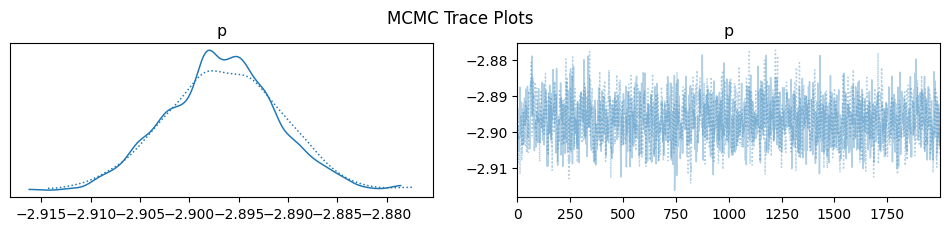

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,-2.897,0.006,-2.907,-2.886,0.0,0.0,1447.0,2020.0,1.0


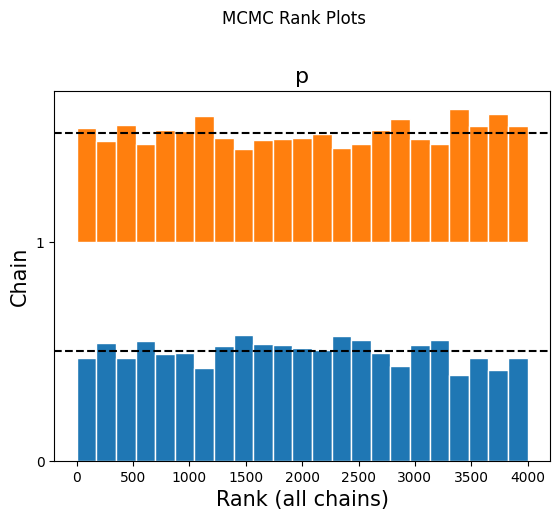

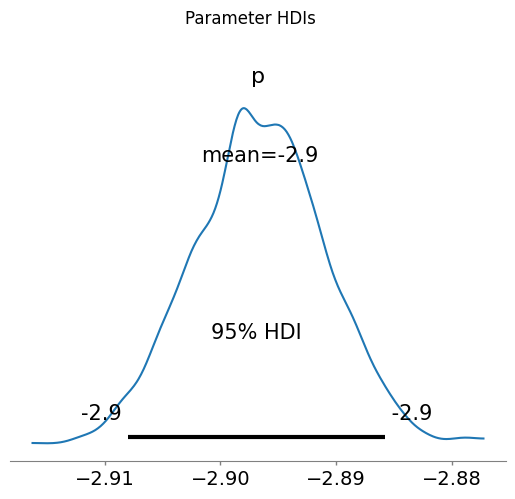

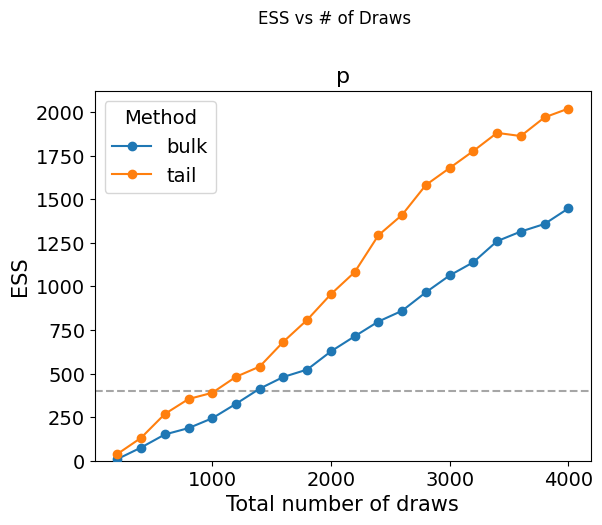

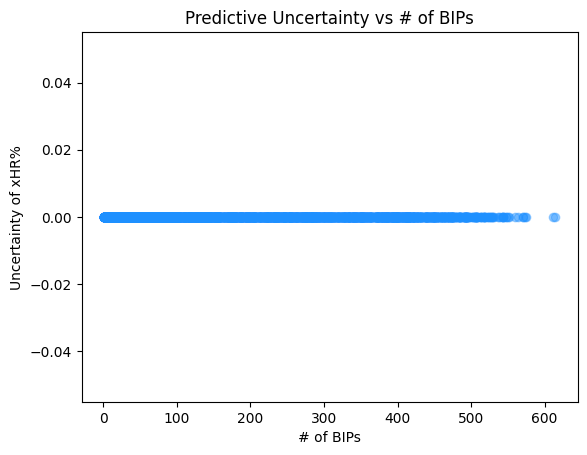

In [60]:
plot_diagnostics(comp_pool_model, master_modeling_player_data, var_names=['p'])

### No Pooling Model

In [ ]:
def no_pooling_model(bips_j, xhrs_j=None, **kwargs):
    """

    # of xHRs in N BIPs for each player ~ Binomial(theta_i), theta_i = completely independent
    """
    n_players = bips_j.shape[0]
    with numpyro.plate("n_players", n_players):
        ## we move p inside --> each player gets their own prob of a success
        p_i = numpyro.sample("p", dist.Normal(-3, 1))
        return numpyro.sample("obs", dist.Binomial(bips_j, logits=p_i), obs=xhrs_j)

In [67]:
coords = {'batter_season': player_data_lagged['batter_season'].values}
dims = {'obs': ['batter_season']}
no_pool_model = run_inference(no_pooling_model, master_modeling_player_data, random.PRNGKey(seed), coords=coords, dims=dims)

mcmc for no_pooling_model


sample: 100%|██████████| 3000/3000 [00:16<00:00, 179.17it/s, 31 steps of size 1.81e-01. acc. prob=0.86]


generate posterior predictions


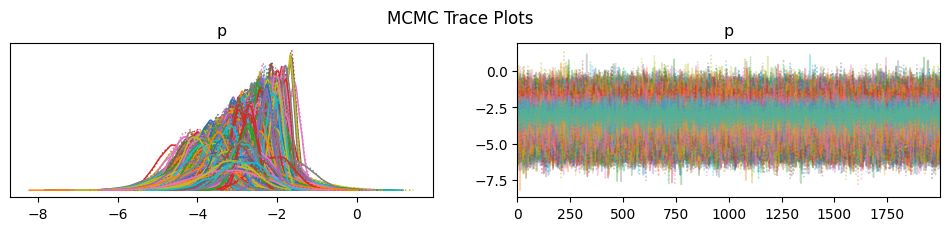

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p[1868],-3.401,0.264,-3.942,-2.942,0.003,0.005,9772.0,2586.0,1.01
p[1431],-3.502,0.828,-4.962,-1.899,0.009,0.017,9592.0,2329.0,1.01
p[2856],-2.505,0.858,-4.035,-0.831,0.009,0.016,10562.0,2977.0,1.01
p[599],-2.949,0.472,-3.842,-2.058,0.005,0.009,9270.0,2686.0,1.01
p[1418],-3.056,0.745,-4.413,-1.669,0.008,0.017,8466.0,2227.0,1.01


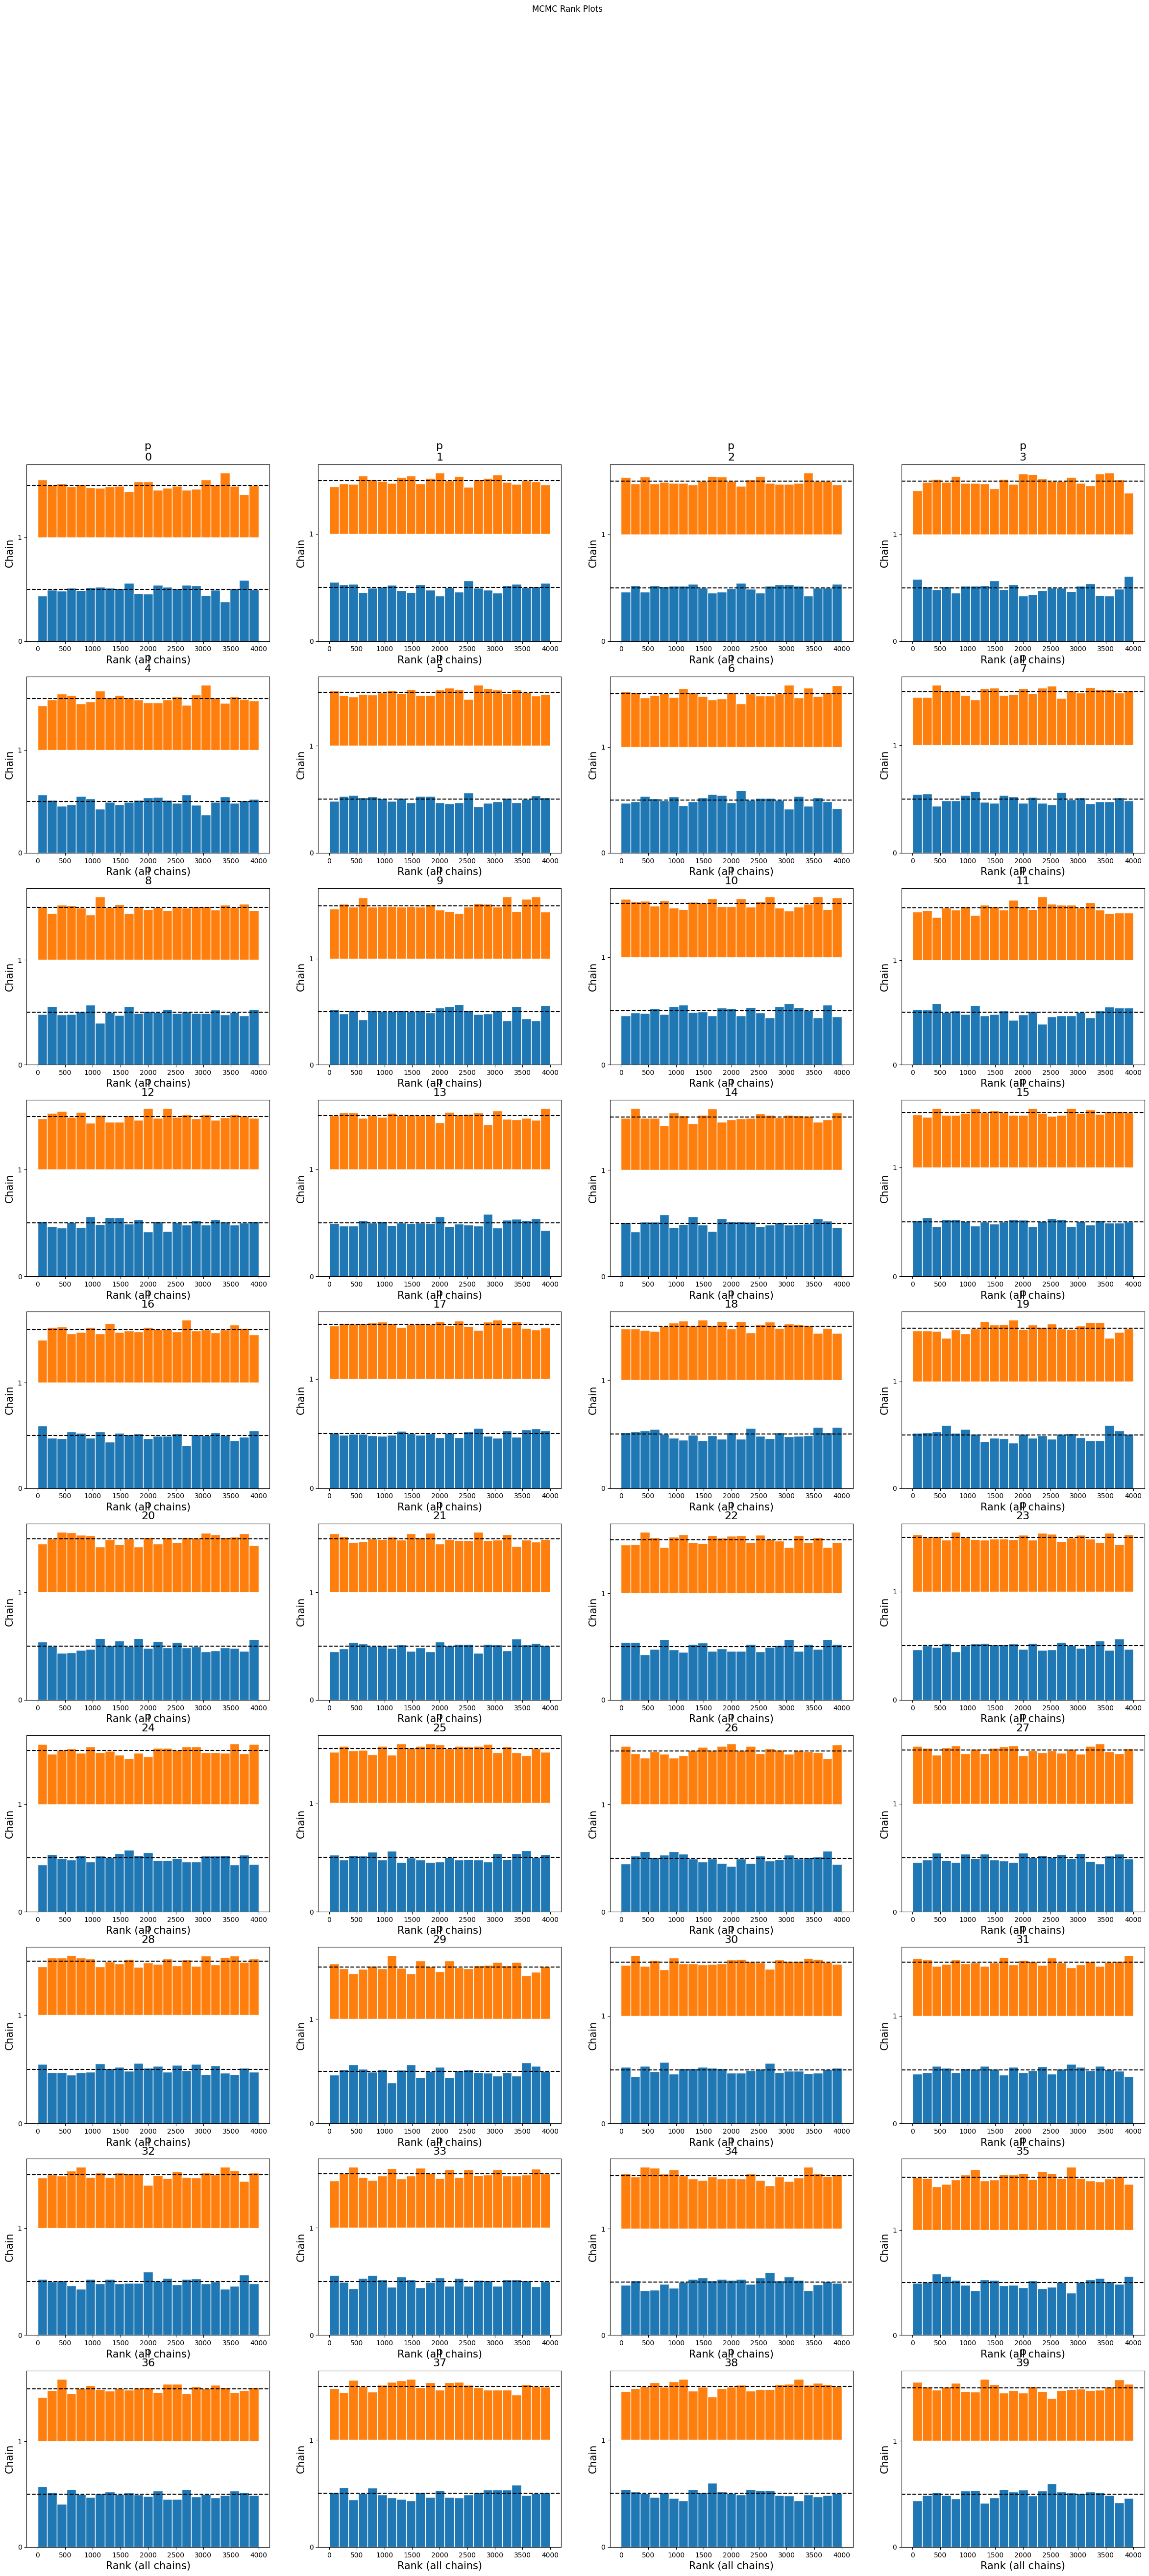

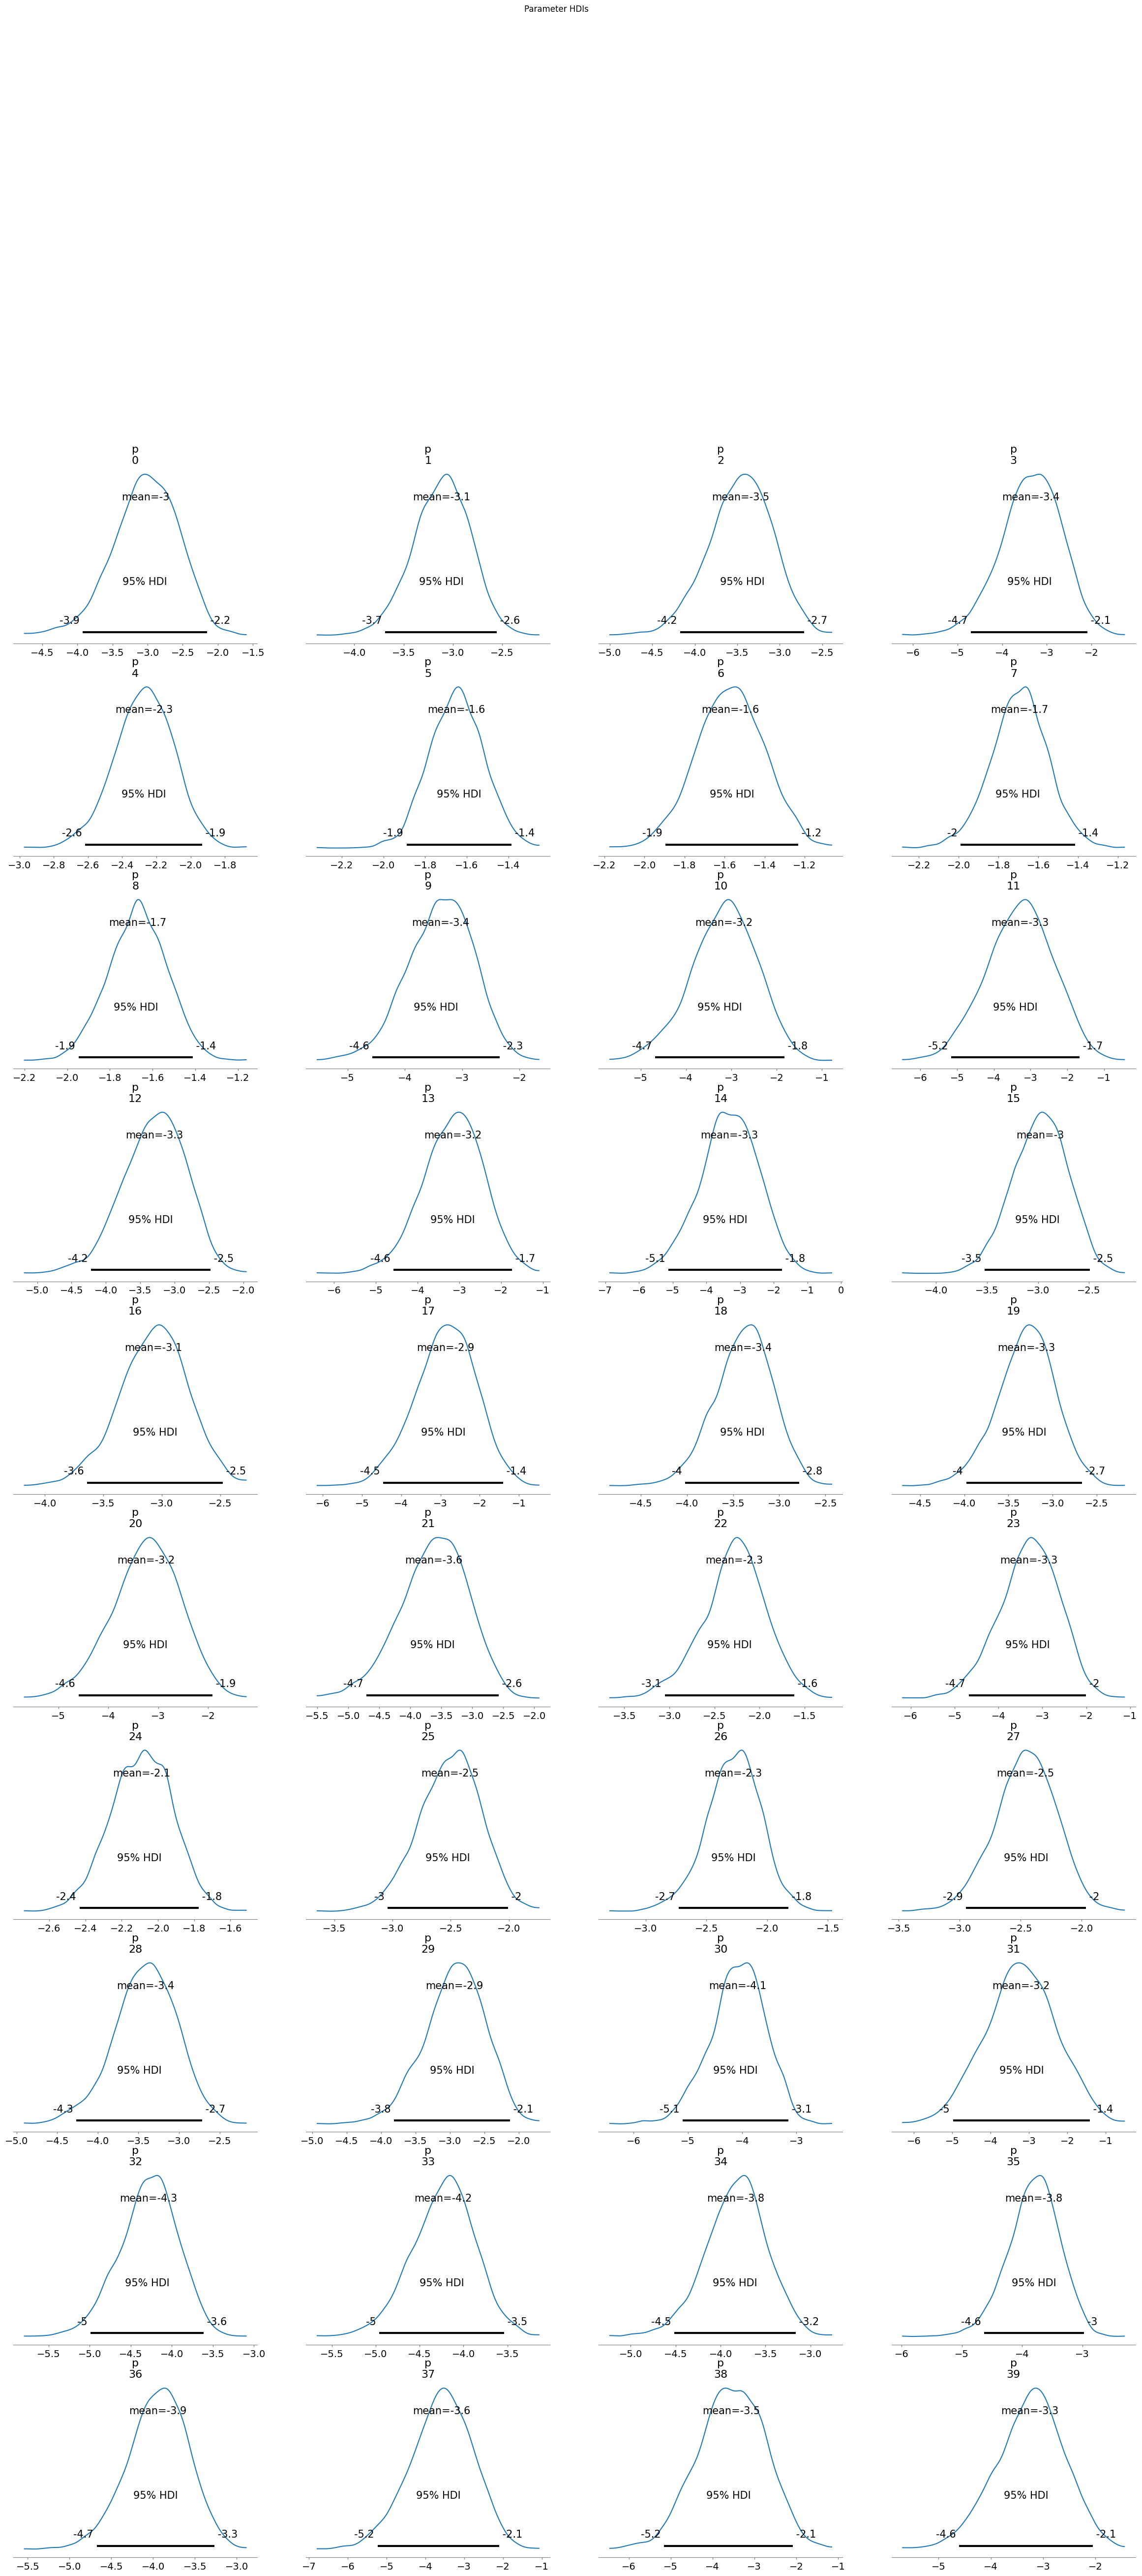

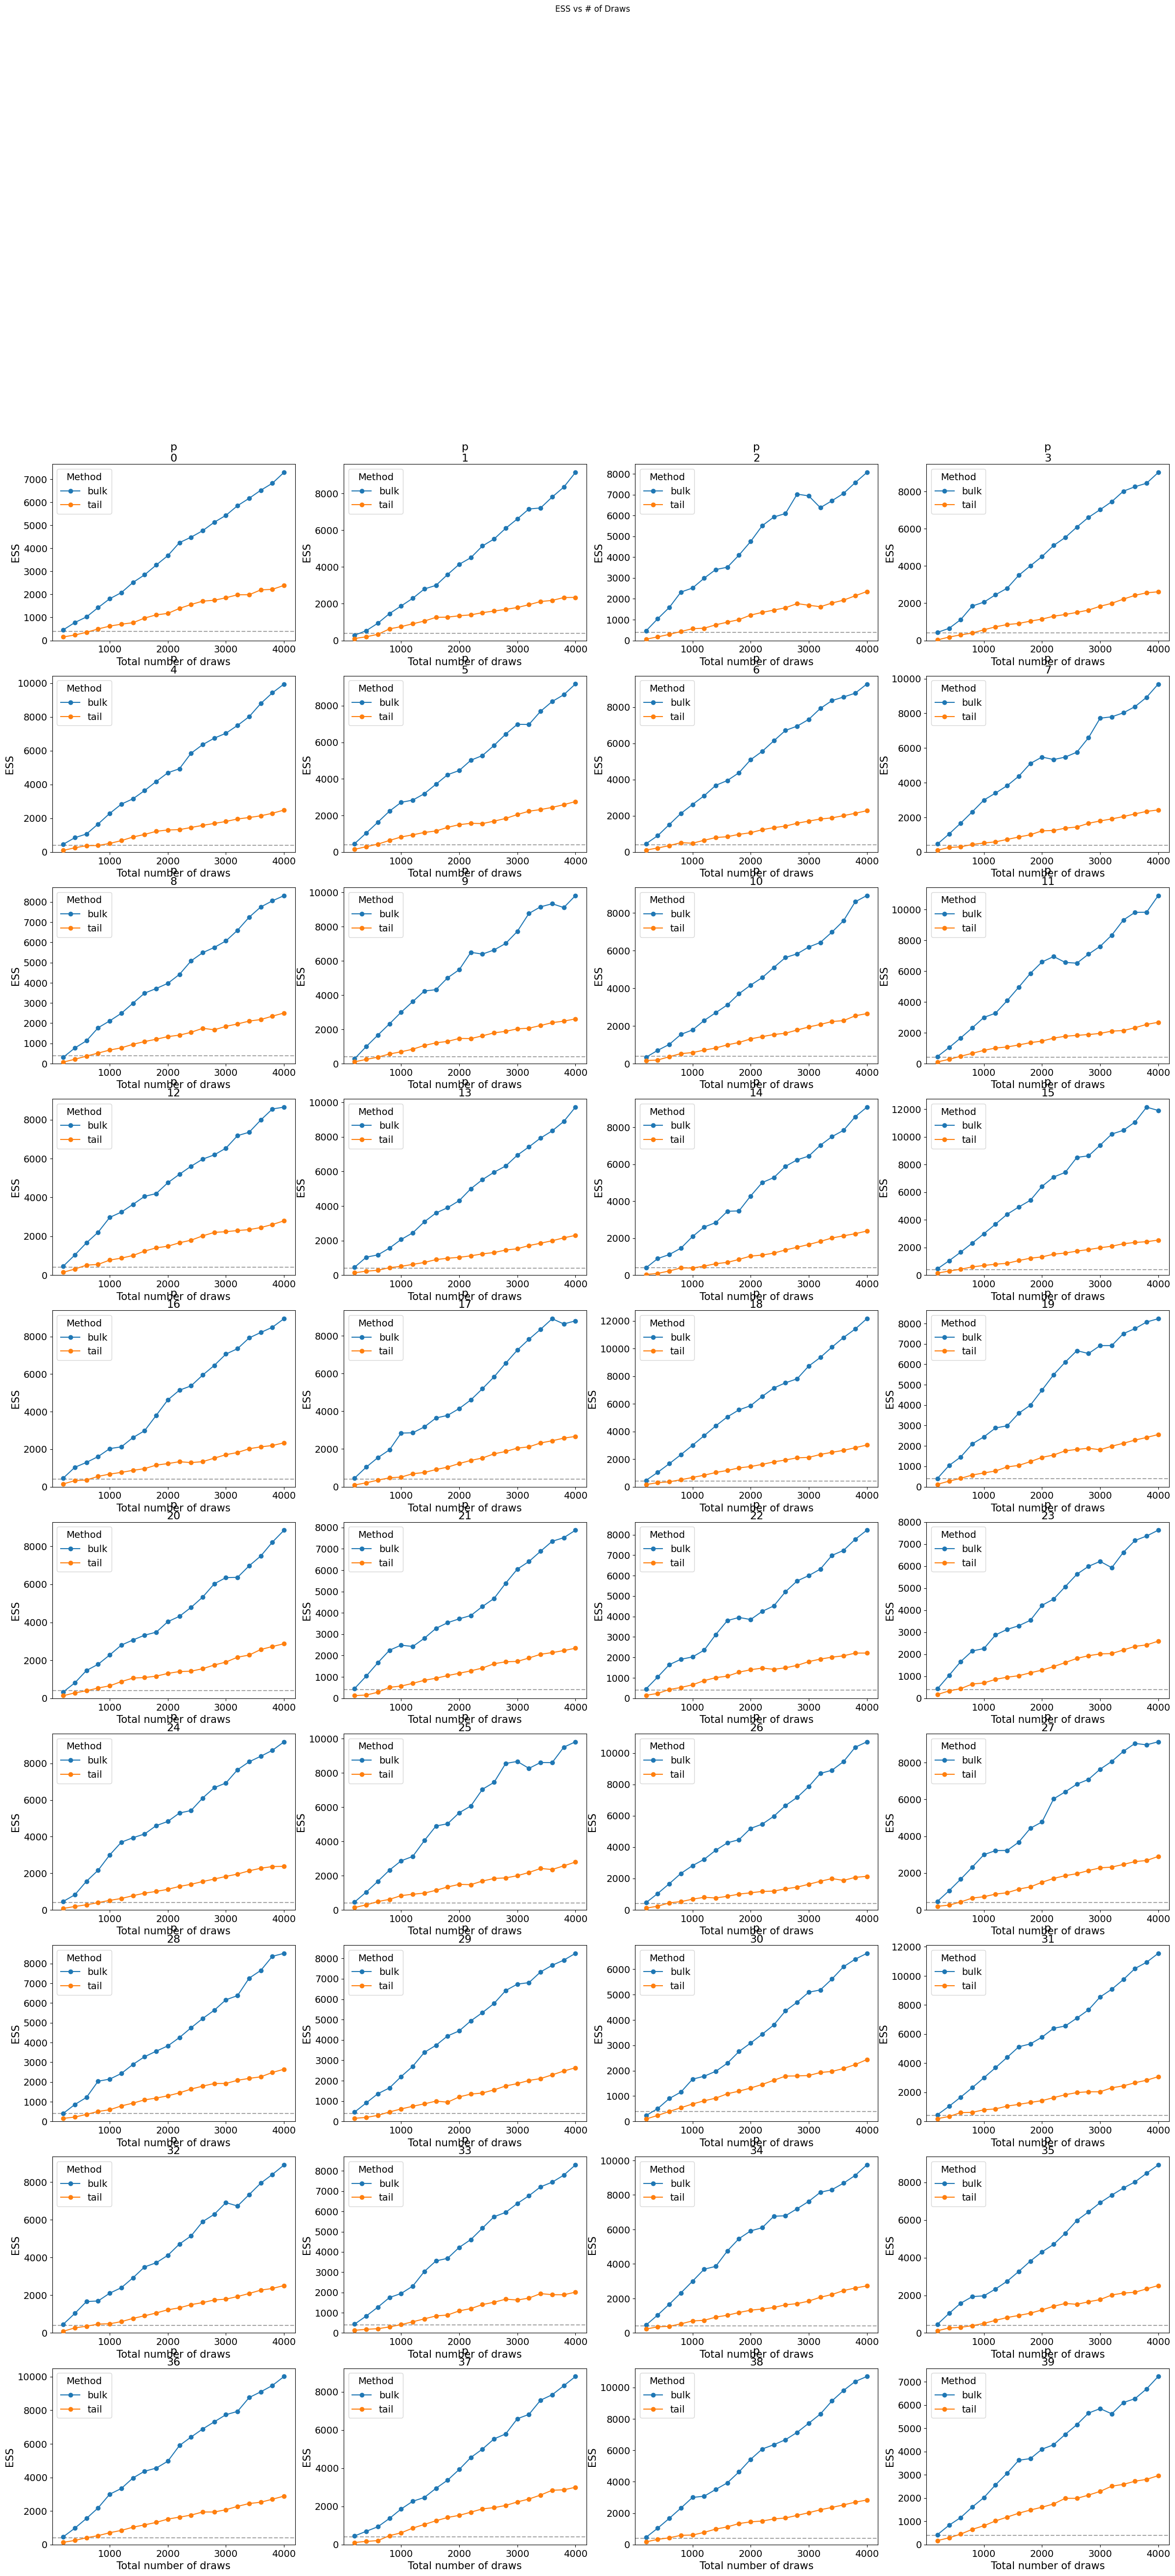

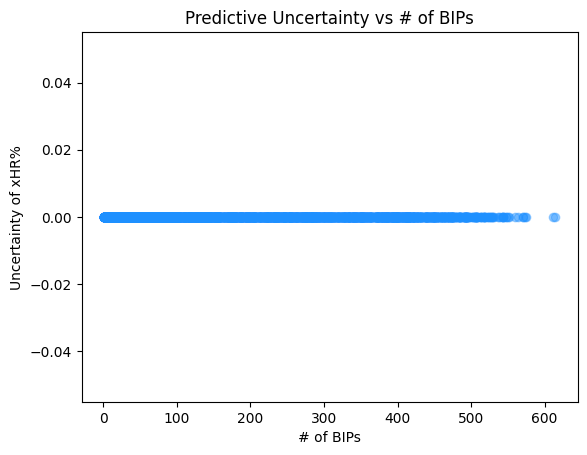

In [68]:
plot_diagnostics(no_pool_model, master_modeling_player_data, var_names=['p'])

### Partial Pooling Models

In [ ]:
def partial_pooling_model_v1(bips, xhrs=None):
    

In [ ]:
from numpyro.infer import log_likelihood
import arviz as az

# 1. Get the log likelihoods for the Complete Pooling model
log_likes = log_likelihood(MCMC.sampler.model, posterior_samples, bips, xhrs=xhrs)

# 2. Convert to an ArviZ InferenceData object
idata_complete = az.from_numpyro(
    mcmc,
    log_likelihood={"obs": log_likes["obs"]}
)